In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv( r"C:\Users\Hp\Desktop\task_Quantium\QVI_purchase_behaviour.csv")


In [3]:
# use raw string to avoid unicode escape and read_excel for .xlsx files
trans = pd.read_excel( r"C:\Users\Hp\Desktop\task_Quantium\QVI_transaction_data.xlsx")


## check Transaction_data :

In [4]:
trans.head(20)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,43604,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
7,43601,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6
8,43332,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9
9,43330,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2


In [5]:
# convert Excel serial DATE to proper datetime
trans['DATE'] = pd.to_numeric(trans['DATE'], errors='coerce')
trans['DATE'] = pd.to_datetime(trans['DATE'], unit='D', origin='1899-12-30')
trans.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [6]:
trans.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [7]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


In [8]:
outliers = trans[trans["PROD_QTY"]> 100]
print(outliers)

            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [9]:
trans= trans[trans["PROD_QTY"]< 100]

In [10]:
trans.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264834,264834.000000,2.648340e+05,2.648340e+05,264834.000000,264834.000000,264834.000000
mean,2018-12-30 00:52:10.292938240,135.079423,1.355488e+05,1.351576e+05,56.583554,1.905813,7.299346
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.000000,7.002100e+04,6.760050e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.000000,1.303570e+05,1.351365e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030940e+05,2.026998e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.784063,8.057990e+04,7.813292e+04,32.826444,0.343436,2.527241


In [11]:
salsa_products = trans[trans['PROD_NAME'].str.lower().str.contains('salsa')]
print(salsa_products['PROD_NAME'].unique())

['Old El Paso Salsa   Dip Tomato Mild 300g'
 'Red Rock Deli SR    Salsa & Mzzrlla 150g'
 'Smiths Crinkle Cut  Tomato Salsa 150g' 'Doritos Salsa       Medium 300g'
 'Old El Paso Salsa   Dip Chnky Tom Ht300g'
 'Woolworths Mild     Salsa 300g'
 'Old El Paso Salsa   Dip Tomato Med 300g'
 'Woolworths Medium   Salsa 300g' 'Doritos Salsa Mild  300g']


In [12]:
trans = trans[~trans["PROD_NAME"].str.lower().str.contains('salsa')]

## Check Cusomer Data :

In [13]:
customer.head(20)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
5,1007,YOUNG SINGLES/COUPLES,Budget
6,1009,NEW FAMILIES,Premium
7,1010,YOUNG SINGLES/COUPLES,Mainstream
8,1011,OLDER SINGLES/COUPLES,Mainstream
9,1012,OLDER FAMILIES,Mainstream


In [14]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [15]:
print(customer.isnull().sum())

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [16]:
print(customer['LIFESTAGE'].unique())
print(customer['PREMIUM_CUSTOMER'].unique())

['YOUNG SINGLES/COUPLES' 'YOUNG FAMILIES' 'OLDER SINGLES/COUPLES'
 'MIDAGE SINGLES/COUPLES' 'NEW FAMILIES' 'OLDER FAMILIES' 'RETIREES']
['Premium' 'Mainstream' 'Budget']


In [17]:
merged_df = pd.merge(trans, customer, on='LYLTY_CARD_NBR', how='inner')

### Merging & Feature Engineering :

In [18]:
merged_df.head(20)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,MIDAGE SINGLES/COUPLES,Budget
7,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,MIDAGE SINGLES/COUPLES,Budget
9,2019-05-17,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget


In [19]:
merged_df['PACK_SIZE'] = merged_df['PROD_NAME'].str.extract('(\d+)').astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Hp\AppData\Local\Temp\ipykernel_6436\3373770053.py:1: SyntaxWarning: invalid escape sequence '\d'
  merged_df['PACK_SIZE'] = merged_df['PROD_NAME'].str.extract('(\d+)').astype(float)


In [20]:
# here extract the first word from the product name to identify the brand
merged_df['BRAND'] = merged_df['PROD_NAME'].str.split().str[0]

brand_replacements = {
    'Red': 'Red Rock Deli',
    'RRD': 'Red Rock Deli',
    'Smiths': 'Smiths',
    'Smith': 'Smiths',
    'Snbts': 'Sunbites',
    'Sunbites': 'Sunbites',
    'Doritos': 'Doritos',
    'Dorito': 'Doritos',
    'Infzns': 'Infuzions',
    'Infuzions': 'Infuzions',
    'WW': 'Woolworths',
    'Woolworths': 'Woolworths',
    'NCC': 'Natural Chip Co',
    'Natural': 'Natural Chip Co'
}

merged_df['BRAND'] = merged_df['BRAND'].replace(brand_replacements)

In [21]:
# here we identify who are the top 10 customers based on total sales

sales_by_segment = merged_df.groupby(['LIFESTAGE','PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_by_segment = sales_by_segment.sort_values(by='TOT_SALES', ascending=False)
print(sales_by_segment.head)

<bound method NDFrame.head of                  LIFESTAGE PREMIUM_CUSTOMER  TOT_SALES
6           OLDER FAMILIES           Budget  156863.75
19   YOUNG SINGLES/COUPLES       Mainstream  147582.20
13                RETIREES       Mainstream  145168.95
15          YOUNG FAMILIES           Budget  129717.95
9    OLDER SINGLES/COUPLES           Budget  127833.60
10   OLDER SINGLES/COUPLES       Mainstream  124648.50
11   OLDER SINGLES/COUPLES          Premium  123537.55
12                RETIREES           Budget  105916.30
7           OLDER FAMILIES       Mainstream   96413.55
14                RETIREES          Premium   91296.65
16          YOUNG FAMILIES       Mainstream   86338.25
1   MIDAGE SINGLES/COUPLES       Mainstream   84734.25
17          YOUNG FAMILIES          Premium   78571.70
8           OLDER FAMILIES          Premium   75242.60
18   YOUNG SINGLES/COUPLES           Budget   57122.10
2   MIDAGE SINGLES/COUPLES          Premium   54443.85
20   YOUNG SINGLES/COUPLES         

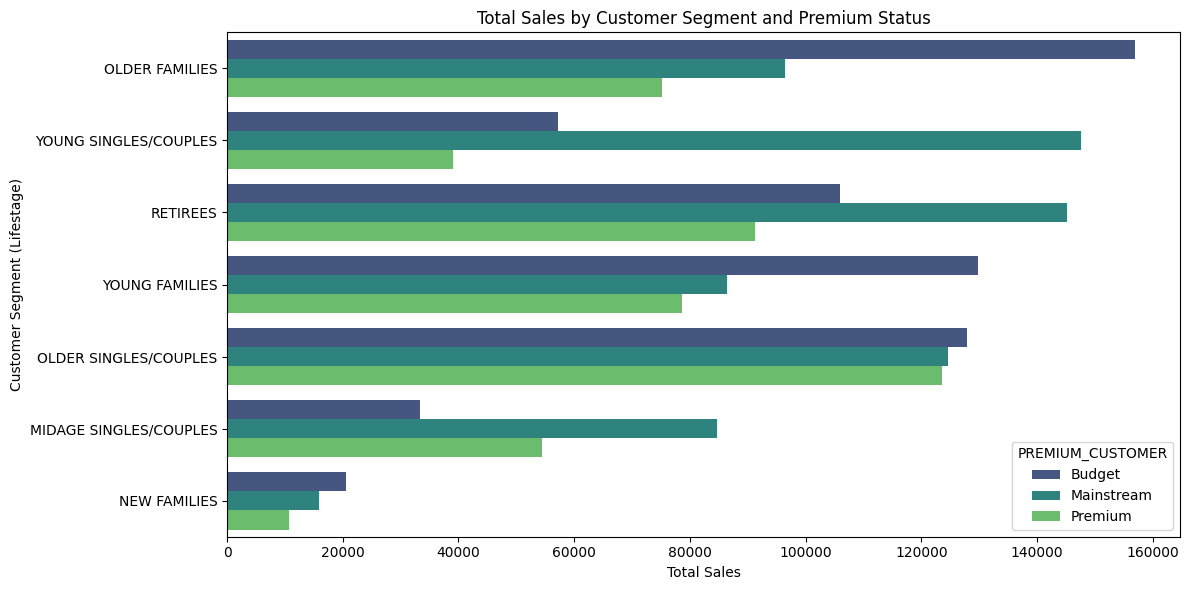

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=sales_by_segment, x='TOT_SALES', y='LIFESTAGE', hue='PREMIUM_CUSTOMER', palette='viridis')
plt.title('Total Sales by Customer Segment and Premium Status')
plt.xlabel('Total Sales')
plt.ylabel('Customer Segment (Lifestage)')
plt.tight_layout()
plt.show()

In [23]:
# now we will focus on the top segments which are Older Families with Budget and Young Singles/Couples with Mainstream
top_segments = merged_df[
    ((merged_df['LIFESTAGE'] == 'OLDER FAMILIES') & (merged_df['PREMIUM_CUSTOMER'] == 'Budget')) |
    ((merged_df['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (merged_df['PREMIUM_CUSTOMER'] == 'Mainstream'))
]

# now we will analyze the pack size preferences for these segments
pack_pref = top_segments.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'PACK_SIZE'])['PROD_QTY'].sum().reset_index()
# now we will sort the pack preferences to find the most preferred pack sizes for each segment
print(pack_pref.sort_values(by=['LIFESTAGE', 'PROD_QTY'], ascending=[True, False]).head(10))

         LIFESTAGE PREMIUM_CUSTOMER  PACK_SIZE  PROD_QTY
10  OLDER FAMILIES           Budget      175.0     11322
6   OLDER FAMILIES           Budget      150.0      6975
4   OLDER FAMILIES           Budget      134.0      3865
2   OLDER FAMILIES           Budget      110.0      3516
9   OLDER FAMILIES           Budget      170.0      3473
8   OLDER FAMILIES           Budget      165.0      2633
18  OLDER FAMILIES           Budget      330.0      2132
17  OLDER FAMILIES           Budget      270.0      1049
19  OLDER FAMILIES           Budget      380.0       993
14  OLDER FAMILIES           Budget      210.0       975


In [24]:
# now we will analyze the brand preferences for these segments
brand_pref = top_segments.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND'])['PROD_QTY'].sum().reset_index()
print(brand_pref.sort_values(by=['LIFESTAGE', 'PROD_QTY'], ascending=[True, False]).head(10))

         LIFESTAGE PREMIUM_CUSTOMER          BRAND  PROD_QTY
10  OLDER FAMILIES           Budget         Kettle      6492
14  OLDER FAMILIES           Budget         Smiths      5717
5   OLDER FAMILIES           Budget        Doritos      3953
12  OLDER FAMILIES           Budget       Pringles      3865
13  OLDER FAMILIES           Budget  Red Rock Deli      3314
20  OLDER FAMILIES           Budget     Woolworths      2355
9   OLDER FAMILIES           Budget      Infuzions      2303
16  OLDER FAMILIES           Budget          Thins      2278
18  OLDER FAMILIES           Budget       Twisties      1593
4   OLDER FAMILIES           Budget           Cobs      1489


#### Recommendation for Category Review:

Target Segment: Focus heavily on the Older Families (Budget) segment, as they drive the highest total sales in the chips category.

Product Optimization: Ensure that shelves are always stocked with 175g and 150g pack sizes, as these are the absolute favorites for this segment.

Brand Positioning: Maximize promotional campaigns and bundle offers for Kettle and Smiths brands targeted at families. Since this segment is budget-conscious but brand-loyal, multi-buy discounts (e.g., "Buy 2 for $X") on these specific brands will significantly drive volume and revenue.

In [25]:
merged_df.to_csv('QVI_clean_data.csv', index=False)

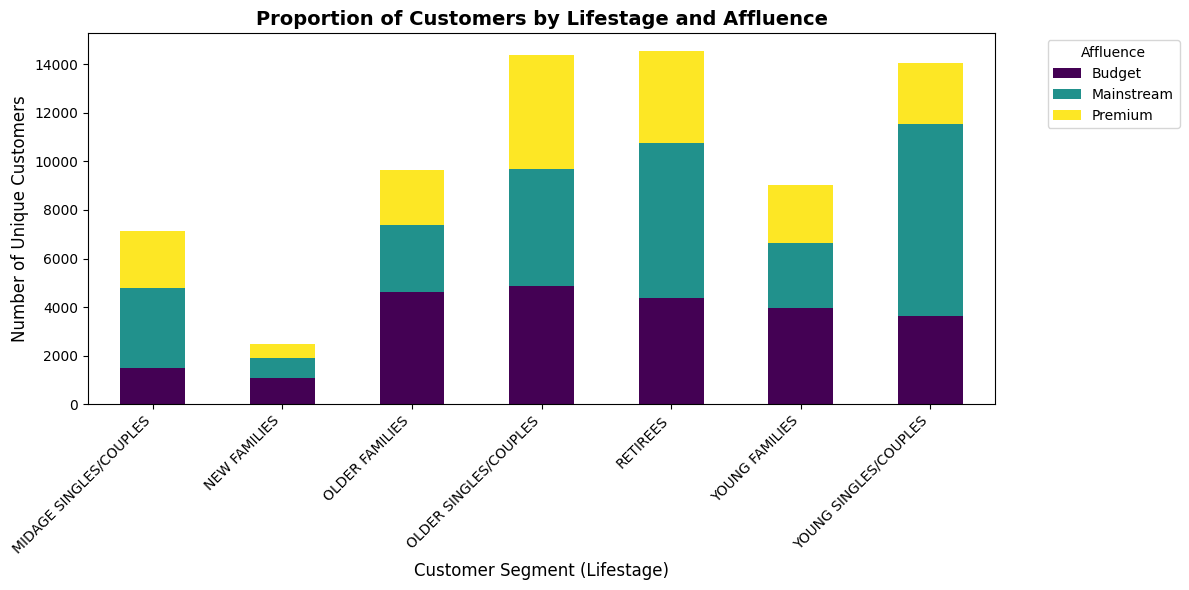

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Group by LIFESTAGE and PREMIUM_CUSTOMER to count unique customers[cite: 4]
customer_counts = merged_df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR'].nunique().unstack()

# 2. Plotting a stacked bar chart
customer_counts.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')

# 3. Formatting the chart for the presentation
plt.title('Proportion of Customers by Lifestage and Affluence', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment (Lifestage)', fontsize=12)
plt.ylabel('Number of Unique Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Affluence', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 4. Show the chart
plt.show()